In [1]:
%load_ext autoreload
%autoreload 2


from paper_utils import *


def get_arg_df():
    # now add the config args to both dfs
    arg_df = []
    for wandbid, config in configs.items():
        try:
            arg_df.append([wandbid] + [config[arg.replace('.', '_')] for arg in args])
        except:
            arg_df.append([wandbid] + [config[arg] for arg in args])
        
    arg_df = pd.DataFrame(arg_df, columns=['wandbid'] + ['c.' + arg for arg in args])

    unique_cols = []
    for column in arg_df.columns[1:]:
        if column == 'name':
            continue
        if len(arg_df[column].unique()) > 1:
            unique_cols += [column]
    uniq_name = 'UNIQ-' + '-'.join(unique_cols)
    arg_df[uniq_name] = arg_df.apply(
        lambda x: '-'.join([str(x[col]) for col in unique_cols]),
        axis=1)


    return arg_df, uniq_name, unique_cols

In [2]:
import wandb

api = wandb.Api()
api_runs = api.runs('goatml/semantic_uncertainty')


In [3]:
args = ['dataset', 'model_name', 'metric', 'entailment_model']


configs = {}

for run in api_runs[:100]:
    finished = run.state == 'finished'
    lot = 'run_25_nov' in run.description
    if lot and finished:
        configs[run.id] = run.config

configs.keys()

dict_keys(['av4gzkg7', 'fr076c4r', 'n0o0k1fj', 'yklbn06w', 'lmu9rk2f', 'yxp1vsb6', 'd2vg99sd', '3hel8mhl', 'wragy6xx', 'gm0va3z5', 'zmzjxzie', 'q7jzuock', 'ps6tsy1w', 'wkoco87o', 'i5pm39lm', 'rtkaljty', '0pw5tnye', '7j2rbwa7', 'tm87ugfd', 'srf6863m', 'p1g0at90', '6eep0pm4', 'rlgiuwt5', 'dn6r1584'])

Sweep over models and datasets.

* For large llama, have ablation over entailment model and metric.
* Some falcon runs failed due to rare error

In [4]:
arg_df, uniq_name, unique_cols = get_arg_df()
arg_df

,wandbid,c.dataset,c.model_name,c.metric,c.entailment_model,UNIQ-c.dataset-c.model_name-c.metric-c.entailment_model
0,av4gzkg7,bioasq,falcon-40b-instruct,squad,deberta,bioasq-falcon-40b-instruct-squad-deberta
1,fr076c4r,squad,falcon-40b,squad,deberta,squad-falcon-40b-squad-deberta
2,n0o0k1fj,bioasq,falcon-40b,squad,deberta,bioasq-falcon-40b-squad-deberta
3,yklbn06w,squad,Llama-2-70b-chat,llm,deberta,squad-Llama-2-70b-chat-llm-deberta
4,lmu9rk2f,squad,Llama-2-70b-chat,squad,Llama-2-70b-chat,squad-Llama-2-70b-chat-squad-Llama-2-70b-chat
5,yxp1vsb6,trivia_qa,Llama-2-70b-chat,llm,deberta,trivia_qa-Llama-2-70b-chat-llm-deberta
6,d2vg99sd,trivia_qa,Llama-2-70b-chat,squad,Llama-2-70b-chat,trivia_qa-Llama-2-70b-chat-squad-Llama-2-70b-chat
7,3hel8mhl,squad,falcon-40b-instruct,squad,deberta,squad-falcon-40b-instruct-squad-deberta
8,wragy6xx,trivia_qa,falcon-40b,squad,deberta,trivia_qa-falcon-40b-squad-deberta
9,gm0va3z5,trivia_qa,falcon-40b-instruct,squad,deberta,trivia_qa-falcon-40b-instruct-squad-deberta


In [6]:
all_results = {}
for wandb_id in configs:
    all_results[wandb_id], _ = restore_file(wandb_id)

In [7]:
runs = {k: arg_df.set_index('wandbid').loc[k][uniq_name] for k in configs}
runs

{'av4gzkg7': 'bioasq-falcon-40b-instruct-squad-deberta',
 'fr076c4r': 'squad-falcon-40b-squad-deberta',
 'n0o0k1fj': 'bioasq-falcon-40b-squad-deberta',
 'yklbn06w': 'squad-Llama-2-70b-chat-llm-deberta',
 'lmu9rk2f': 'squad-Llama-2-70b-chat-squad-Llama-2-70b-chat',
 'yxp1vsb6': 'trivia_qa-Llama-2-70b-chat-llm-deberta',
 'd2vg99sd': 'trivia_qa-Llama-2-70b-chat-squad-Llama-2-70b-chat',
 '3hel8mhl': 'squad-falcon-40b-instruct-squad-deberta',
 'wragy6xx': 'trivia_qa-falcon-40b-squad-deberta',
 'gm0va3z5': 'trivia_qa-falcon-40b-instruct-squad-deberta',
 'zmzjxzie': 'bioasq-Llama-2-70b-chat-llm-deberta',
 'q7jzuock': 'bioasq-Llama-2-70b-chat-squad-Llama-2-70b-chat',
 'ps6tsy1w': 'squad-Llama-2-7b-squad-deberta',
 'wkoco87o': 'trivia_qa-Llama-2-7b-squad-deberta',
 'i5pm39lm': 'squad-Llama-2-70b-squad-deberta',
 'rtkaljty': 'squad-Llama-2-70b-chat-squad-deberta',
 '0pw5tnye': 'bioasq-Llama-2-7b-squad-deberta',
 '7j2rbwa7': 'trivia_qa-Llama-2-70b-squad-deberta',
 'tm87ugfd': 'trivia_qa-Llama-2-7

In [7]:
# Re-Run (possible rare bug in token for some hidden states (~1/100))

# runs = {
#     'av4gzkg7': 'bioasq-falcon-40b-instruct-squad-deberta',
#     'fr076c4r': 'squad-falcon-40b-squad-deberta',
#     'n0o0k1fj': 'bioasq-falcon-40b-squad-deberta',
#     'yklbn06w': 'squad-Llama-2-70b-chat-llm-deberta',
#     'lmu9rk2f': 'squad-Llama-2-70b-chat-squad-Llama-2-70b-chat',
#     'yxp1vsb6': 'trivia_qa-Llama-2-70b-chat-llm-deberta',
#     'd2vg99sd': 'trivia_qa-Llama-2-70b-chat-squad-Llama-2-70b-chat',
#     '3hel8mhl': 'squad-falcon-40b-instruct-squad-deberta',
#     'wragy6xx': 'trivia_qa-falcon-40b-squad-deberta',
#     'gm0va3z5': 'trivia_qa-falcon-40b-instruct-squad-deberta',
#     'zmzjxzie': 'bioasq-Llama-2-70b-chat-llm-deberta',
#     'q7jzuock': 'bioasq-Llama-2-70b-chat-squad-Llama-2-70b-chat',
#     'ps6tsy1w': 'squad-Llama-2-7b-squad-deberta',
#     'wkoco87o': 'trivia_qa-Llama-2-7b-squad-deberta',
#     'i5pm39lm': 'squad-Llama-2-70b-squad-deberta',
#     'rtkaljty': 'squad-Llama-2-70b-chat-squad-deberta',
#     '0pw5tnye': 'bioasq-Llama-2-7b-squad-deberta',
#     '7j2rbwa7': 'trivia_qa-Llama-2-70b-squad-deberta',
#     'tm87ugfd': 'trivia_qa-Llama-2-70b-chat-squad-deberta',
#     'srf6863m': 'squad-Llama-2-7b-chat-squad-deberta',
#     'p1g0at90': 'trivia_qa-Llama-2-7b-chat-squad-deberta',
#     '6eep0pm4': 'bioasq-Llama-2-7b-chat-squad-deberta',
#     'rlgiuwt5': 'bioasq-Llama-2-70b-squad-deberta',
#     'dn6r1584': 'bioasq-Llama-2-70b-chat-squad-deberta'}
# }


model,bioasq,squad,trivia_qa
dataset,,,
Llama-2-70b-chat-llm-deberta,0.5300,0.2925,0.8050
Llama-2-70b-chat-squad-Llama-2-70b-chat,0.5225,0.3125,0.7450
Llama-2-70b-chat-squad-deberta,0.5225,0.3225,0.7475
Llama-2-70b-squad-deberta,0.5425,0.4000,0.7850
Llama-2-7b-chat-squad-deberta,0.4500,0.2450,0.6125
Llama-2-7b-squad-deberta,0.4475,0.2700,0.6375
falcon-40b-instruct-squad-deberta,0.5000,0.3000,0.7125
falcon-40b-squad-deberta,0.5250,0.3100,0.6975


Text(0, 0.5, 'accuracy')

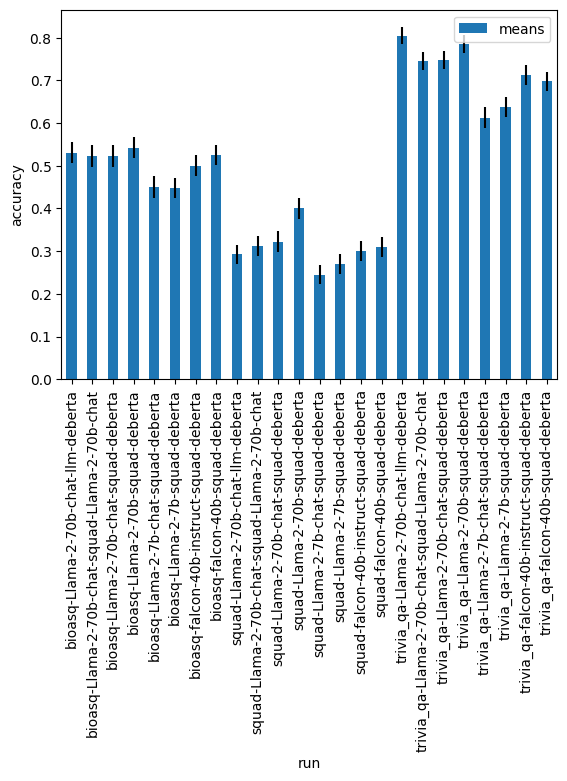

In [8]:
def get_perf_df(runs, all_results=all_results):
    perfdf = {}
    for wandb_id, run_name in runs.items():
        results = all_results[wandb_id]    
        perfdf[wandb_id] = get_perfs(results)
    
    runids = list(perfdf.keys())
    tmp = pd.DataFrame(perfdf[runids[0]])
    tmp['wandbid'] = runids[0]
    tmp['run'] = runs[runids[0]]
    
    for runid in runids[1:]:
        tmp2 = pd.DataFrame(perfdf[runid])
        tmp2['wandbid'] = runid
        tmp2['run'] = runs[runid]
        
        tmp = pd.concat([tmp, tmp2])
    
    perfdf = tmp.reset_index()
    
    tmp = perfdf.set_index('method').loc['accuracy']
    tmp['model'] = tmp.run.map(lambda x: '-'.join(x.split('-')[:1]))
    tmp['dataset'] = tmp.run.map(lambda x: '-'.join(x.split('-')[1:]))
    display(tmp.pivot(columns='model', index='dataset', values='means'))

    pdfs = {}
    for wandb_id in runs:
        results = all_results[wandb_id]
        pdfs[wandb_id] = get_uncertainty_df(results)
    
    runids = list(pdfs.keys())

    tmp = pd.DataFrame(pdfs[runids[0]])
    tmp['run'] = runs[runids[0]]
    tmp['wandbid'] = runids[0]
    
    for runid in runids[1:]:
        tmp2 = pd.DataFrame(pdfs[runid])
        tmp2['run'] = runs[runid]
        tmp2['wandbid'] = runid
    
        tmp = pd.concat([tmp, tmp2])
    
    all_runs = tmp.reset_index()

    return perfdf, pdfs, all_runs

perfdf, pdfs, all_runs = get_perf_df(runs)

perfdf = perfdf.merge(arg_df, on='wandbid')
all_runs = all_runs.merge(arg_df, on='wandbid')

plot_bar(perfdf.set_index('method').loc['accuracy'].set_index('run').sort_index())
plt.gca().set_ylabel('accuracy')

/auto/users/jansen/semantic_uncertainty/notebooks/paper_evals/paper_utils.py:163: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90);


Text(0, 0.5, 'accuracy')

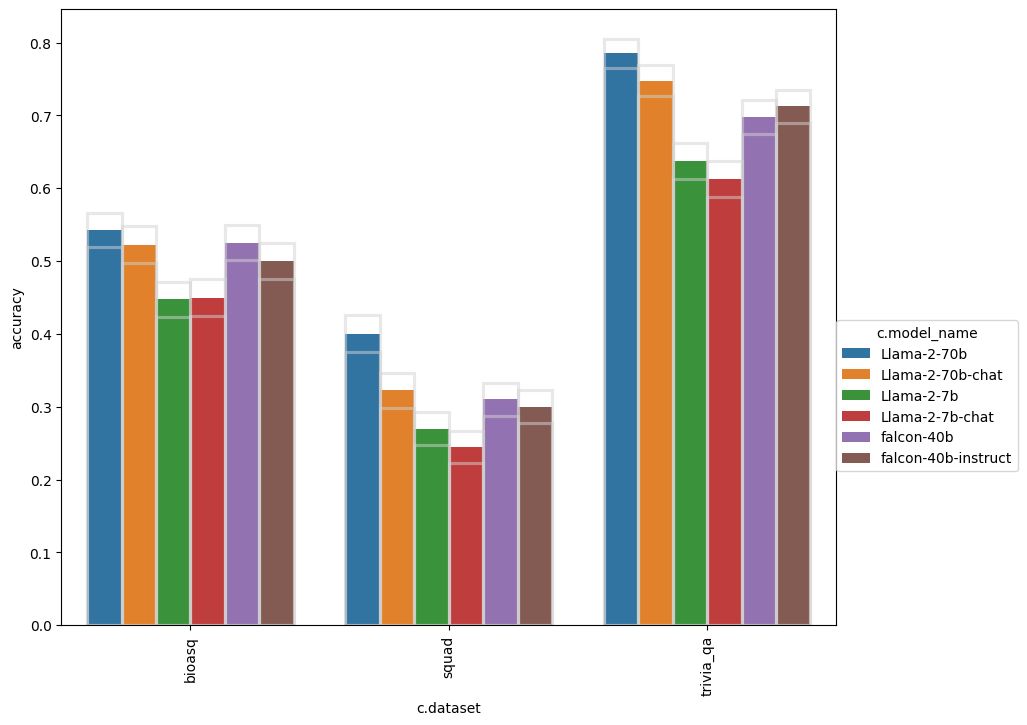

In [9]:
# just select the base entailment_model and metric, and ignore 'max_from' accuracies
acc = 'accuracy'
plot_grouped(perfdf.set_index('c.entailment_model').loc['deberta'].set_index('c.metric').loc['squad'].set_index('method').loc[acc], metric='means', x='c.dataset', hue='c.model_name')
plt.gca().set_ylabel(acc)

In [21]:
print(', ' .join(list(arg_df['c.model_name'].unique())))

falcon-40b-instruct, falcon-40b, Llama-2-70b-chat, Llama-2-7b, Llama-2-70b, Llama-2-7b-chat


/auto/users/jansen/semantic_uncertainty/notebooks/paper_evals/paper_utils.py:163: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90);


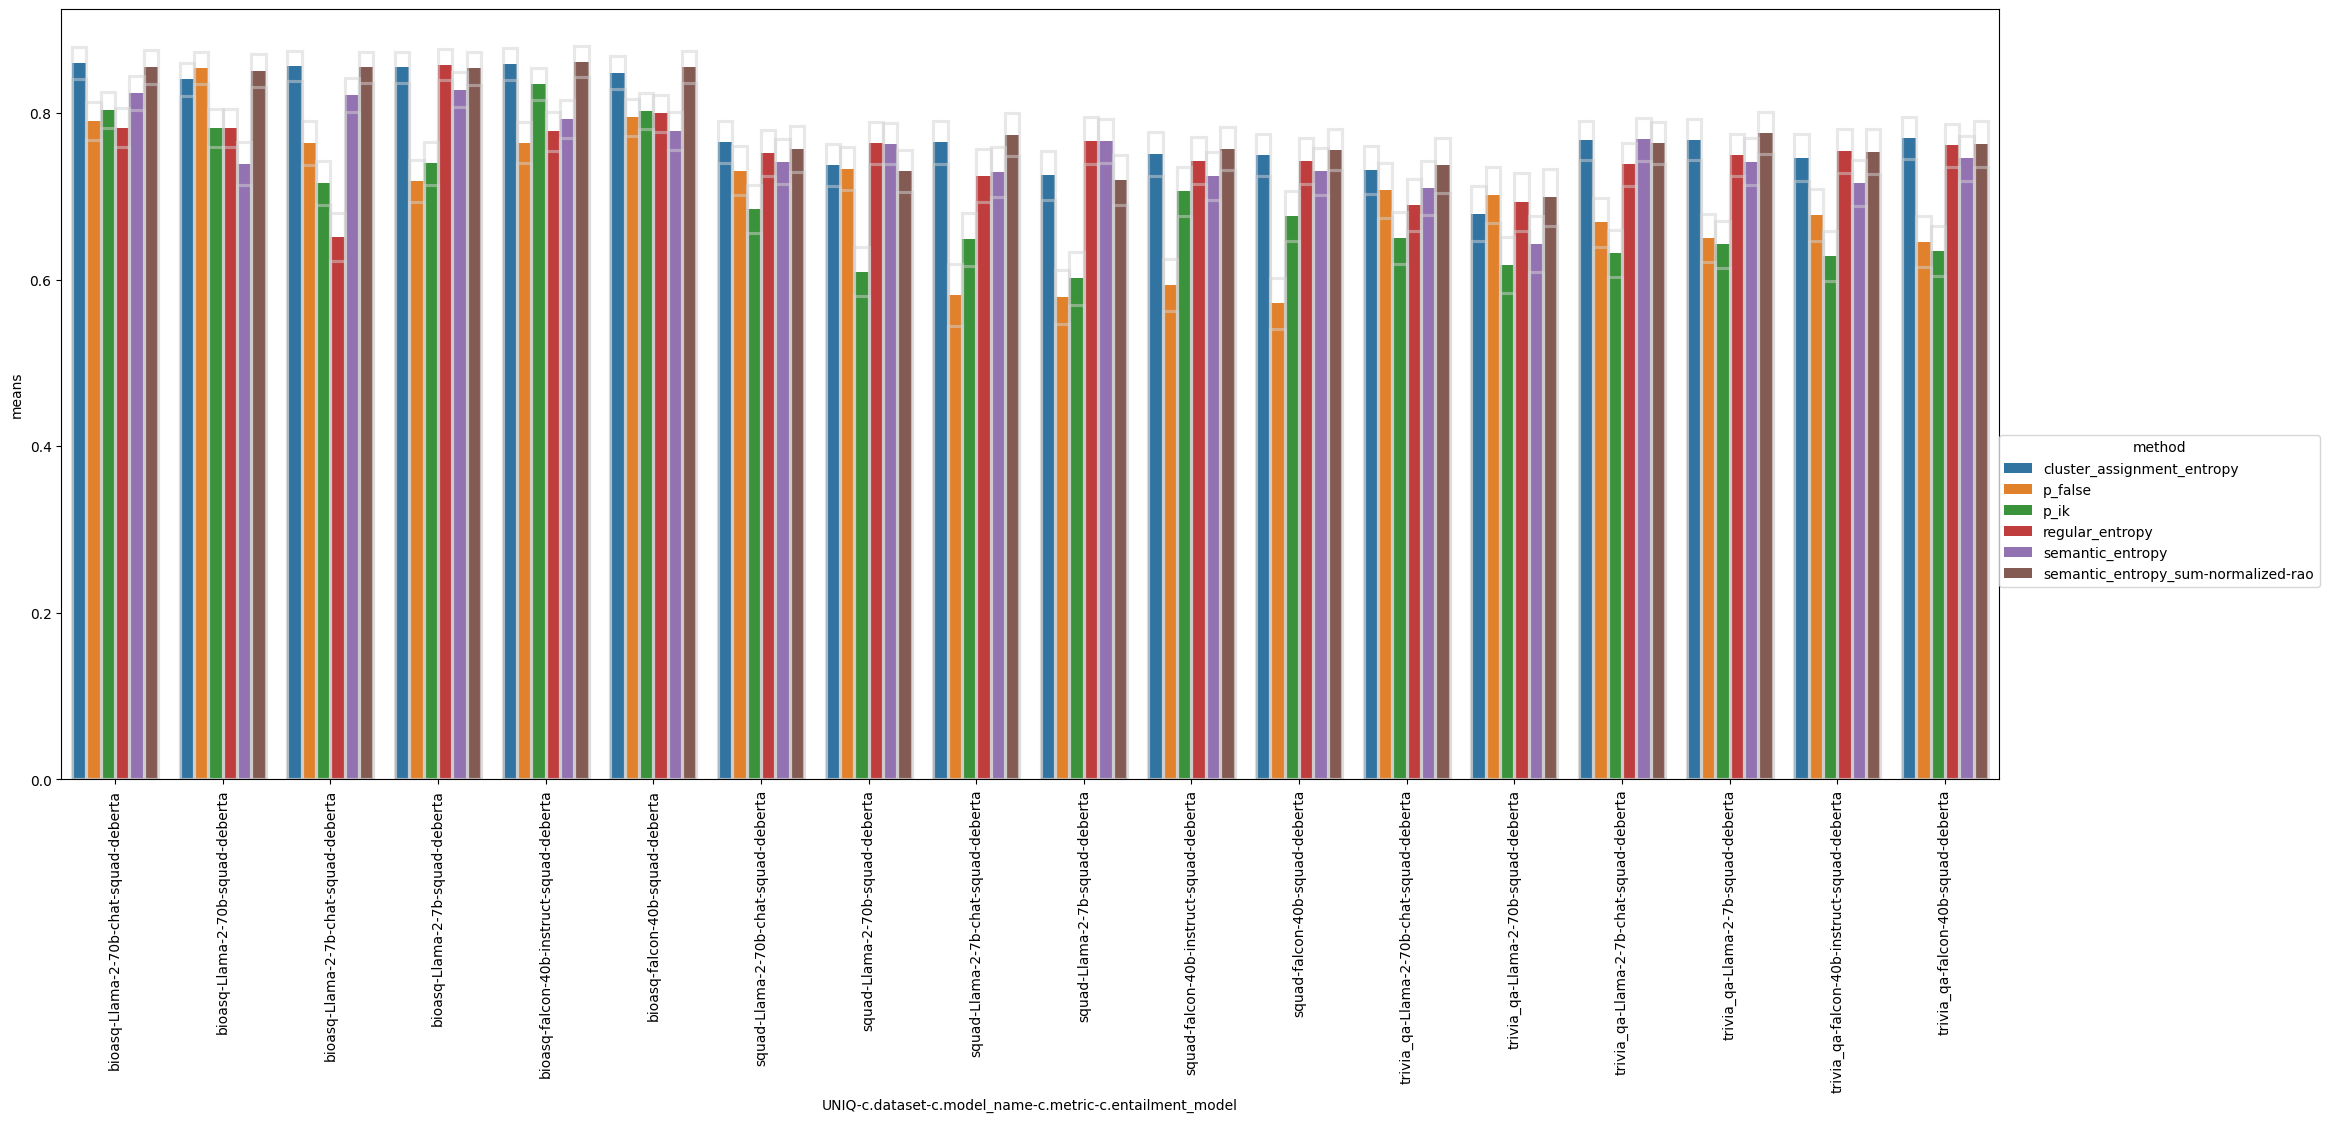

In [10]:

main_methods = ['cluster_assignment_entropy', 'regular_entropy', 'semantic_entropy', 'p_ik', 'p_false', 'semantic_entropy_sum-normalized-rao']

plot_grouped(
    all_runs.set_index('c.entailment_model').loc['deberta'].set_index('c.metric').loc['squad'].set_index('metric').loc['AUROC'].set_index('method').loc[main_methods].reset_index(),
    metric='means', x=uniq_name, hue='method',
    figsize=(25, 10)
)

plot the same, but per dataset

(actually, semantic entropy (and variants), are not that bad overall, especially once you start taking smaller models into account (where e.g. p_false oftens sucks))

/auto/users/jansen/semantic_uncertainty/notebooks/paper_evals/paper_utils.py:163: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90);
/auto/users/jansen/semantic_uncertainty/notebooks/paper_evals/paper_utils.py:163: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90);
/auto/users/jansen/semantic_uncertainty/notebooks/paper_evals/paper_utils.py:163: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90);


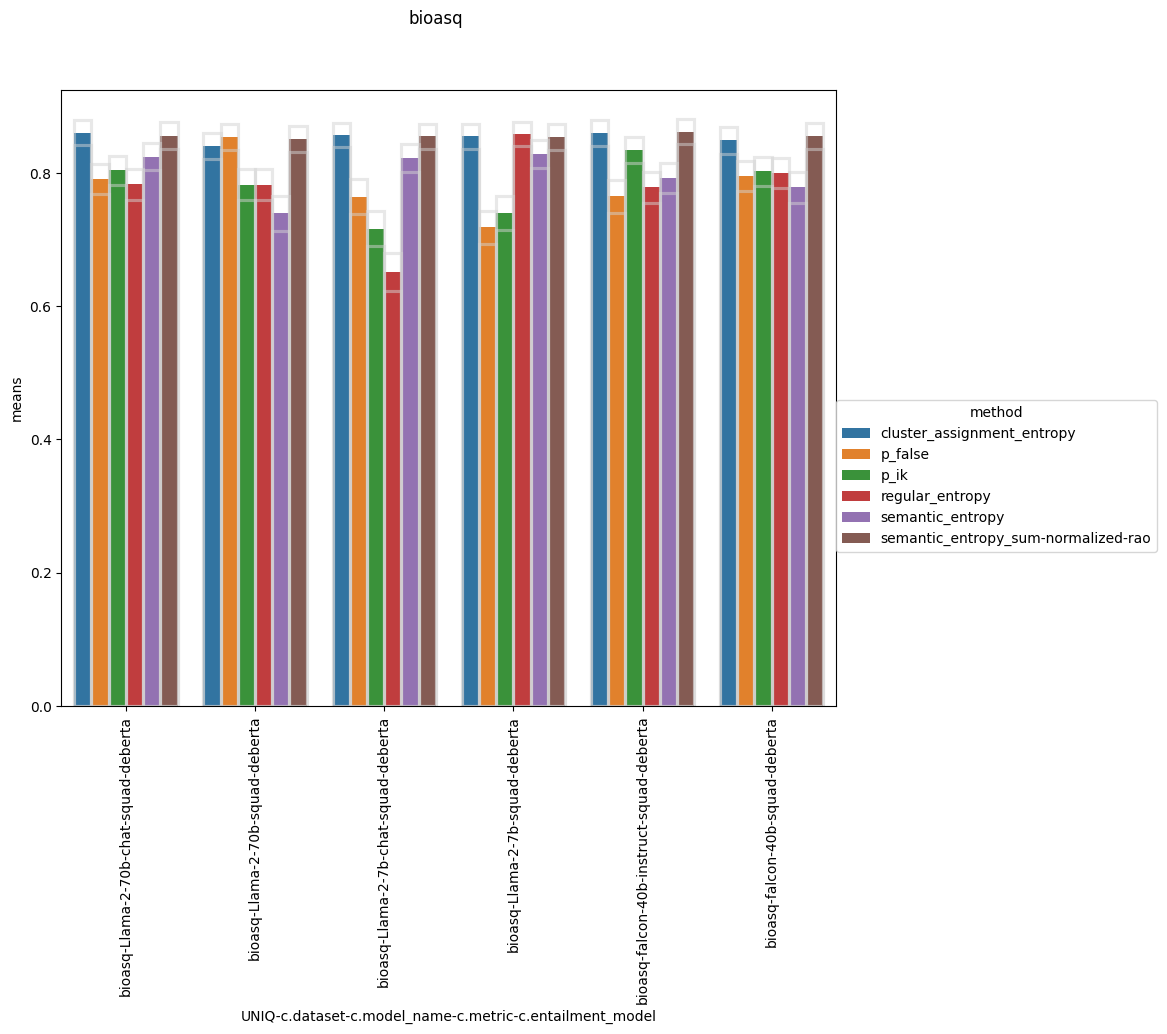

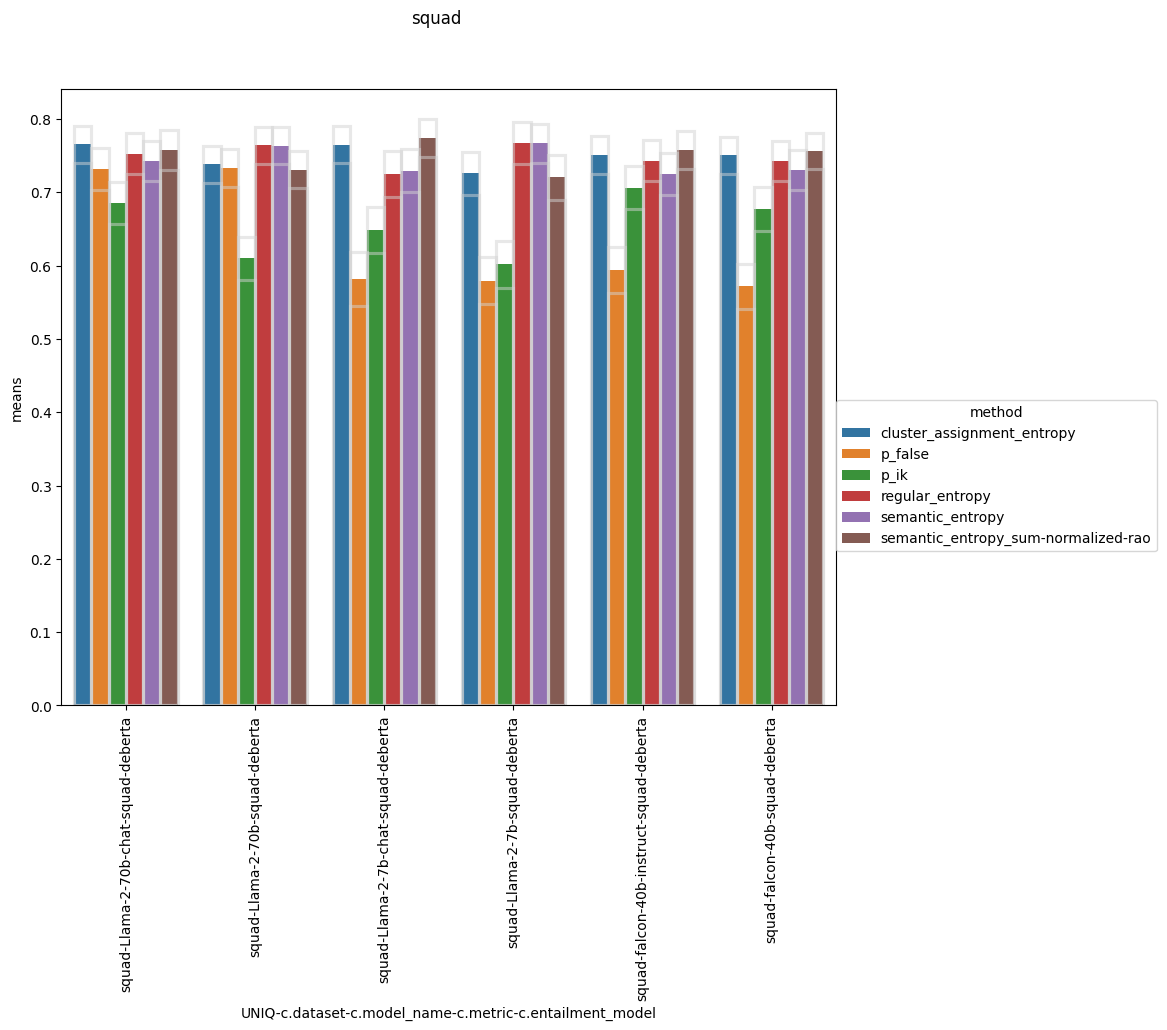

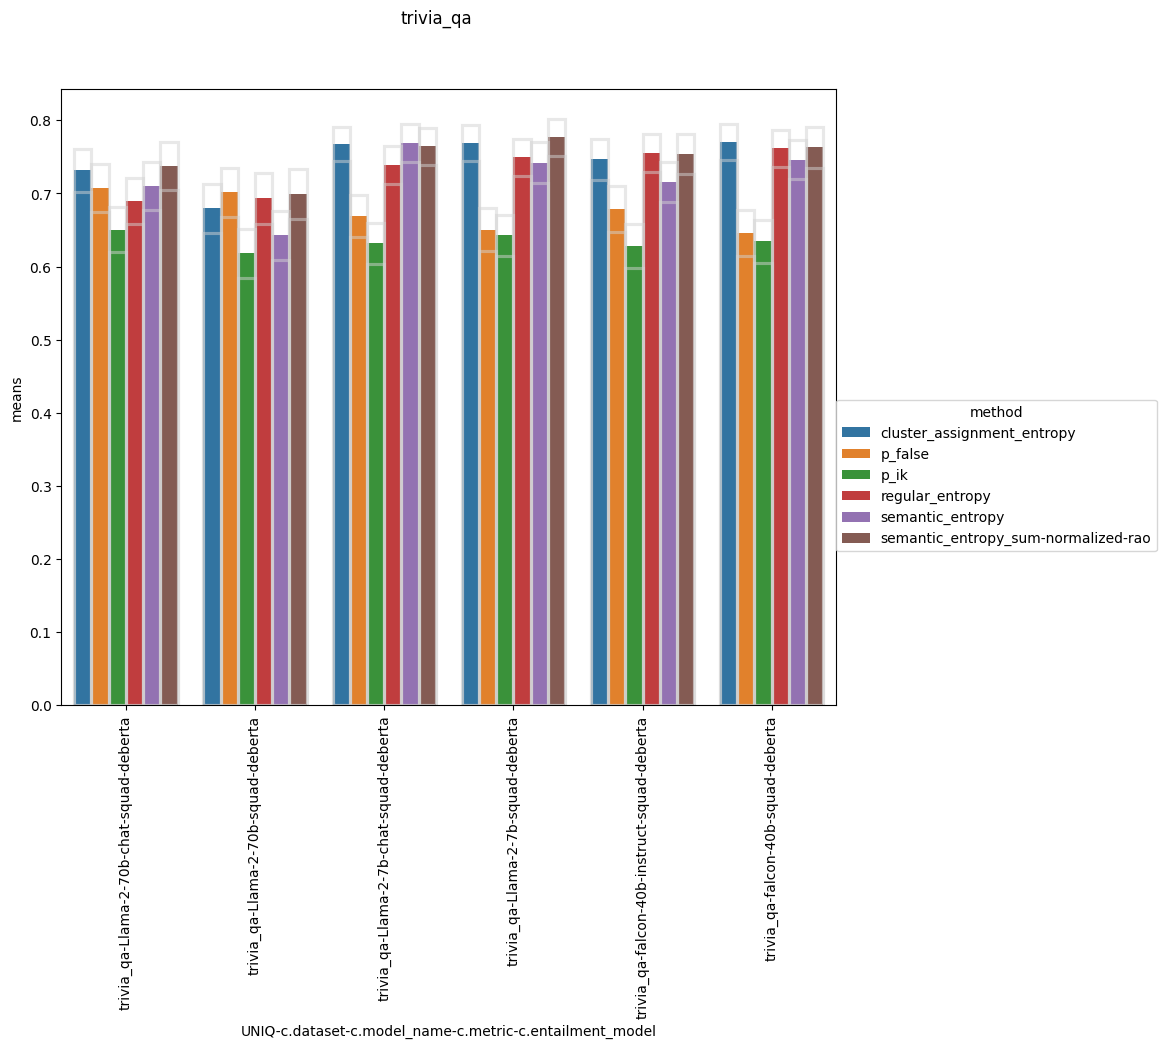

In [11]:
for dataset, gdf in all_runs.groupby('c.dataset'):

    plot_grouped(
        gdf.set_index('c.entailment_model').loc['deberta'].set_index('c.metric').loc['squad'].set_index('metric').loc['AUROC'].set_index('method').loc[main_methods].reset_index(),
        metric='means', x=uniq_name, hue='method',
    )
    plt.gcf().suptitle(dataset)

In [13]:
# note that instead of low/high, should probably compute the standard error over the mean here! (if there are enough categories that we average over!)

tmp = all_runs.set_index('metric').loc['AUROC']

# select main runs (they have deberta entailment and squad metric)
tmp = tmp.set_index('c.entailment_model').loc['deberta'].set_index('c.metric').loc['squad']
tmp = tmp[tmp.method.map(lambda x: 'UNANSWERABLE' not in x)]
tmp.groupby('method').mean('means').sort_values('means', ascending=False)

,means,low,high
method,,,
semantic_entropy_sum-normalized-rao_max_from_semantic_entropy_sum-normalized-rao,0.786852,0.761903,0.811801
semantic_entropy_sum-normalized-rao,0.784703,0.759732,0.809675
cluster_assignment_entropy,0.782301,0.758123,0.806479
regular_entropy_sum,0.769951,0.745211,0.794690
semantic_entropy,0.753773,0.727558,0.779989
regular_entropy,0.752017,0.725538,0.778496
semantic_entropy_max_from_semantic_entropy,0.751926,0.725355,0.778497
semantic_entropy_sum,0.741143,0.715586,0.766701
semantic_entropy_sum_cmean,0.734197,0.708217,0.760178


In [14]:
# now lets look at the diffs between the entailment models / metric choices --> I have those only for 'Llama-2-70b-chat'



/auto/users/jansen/semantic_uncertainty/notebooks/paper_evals/paper_utils.py:163: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90);
/auto/users/jansen/semantic_uncertainty/notebooks/paper_evals/paper_utils.py:163: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90);
/auto/users/jansen/semantic_uncertainty/notebooks/paper_evals/paper_utils.py:163: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90);


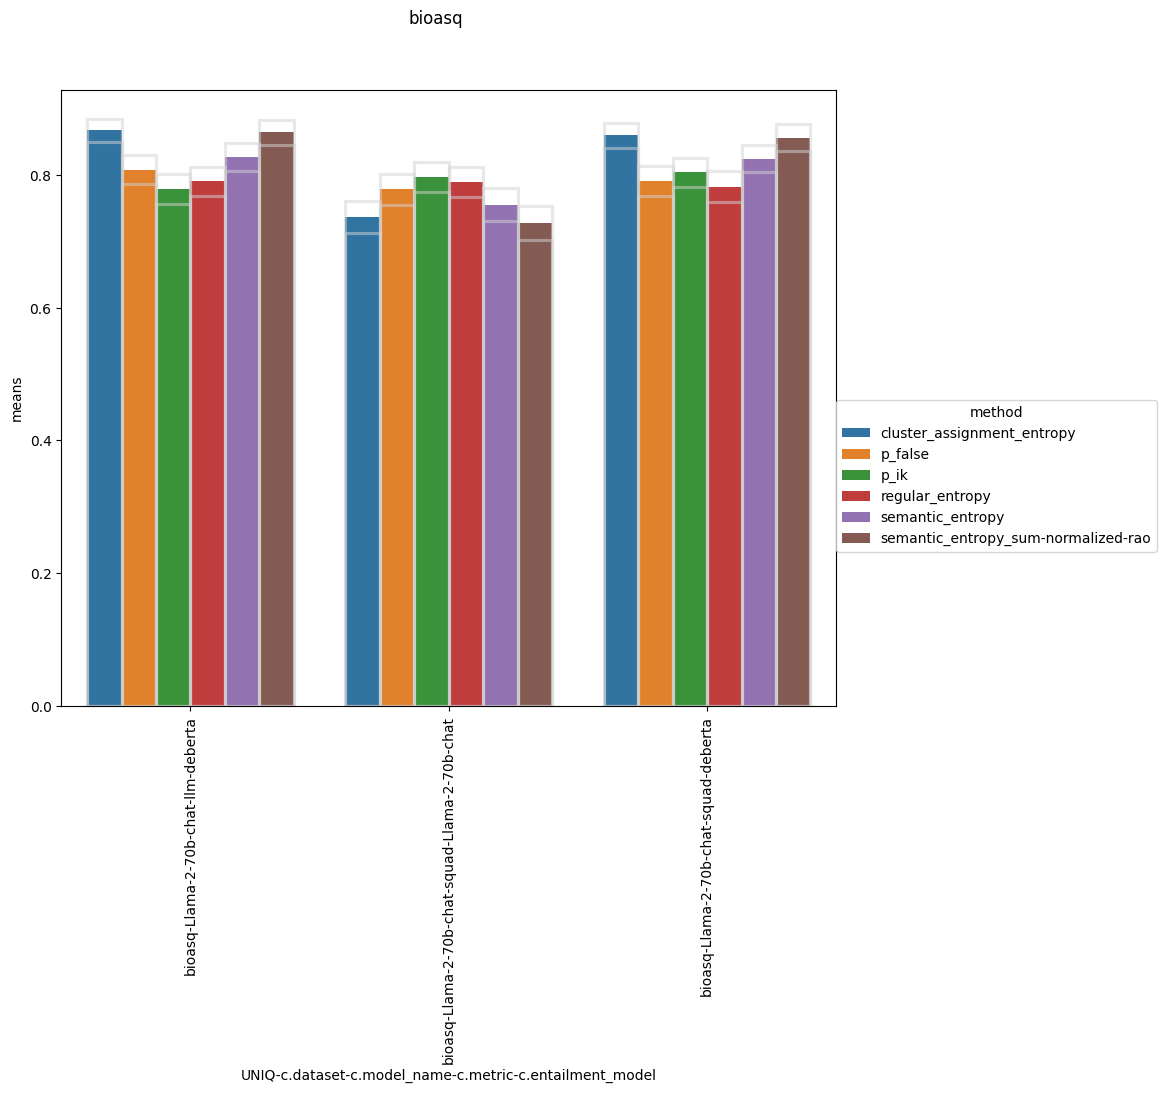

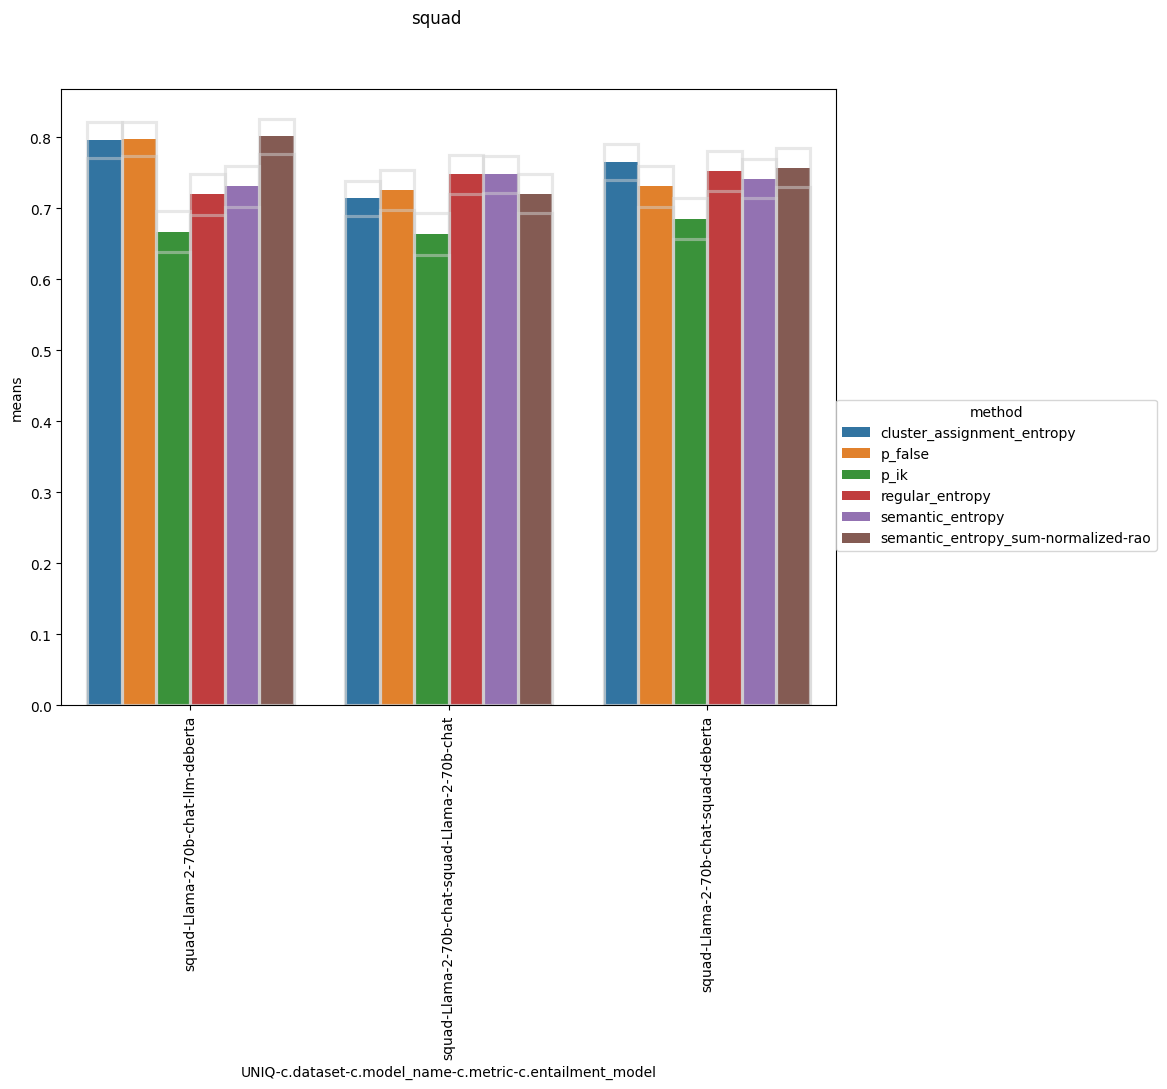

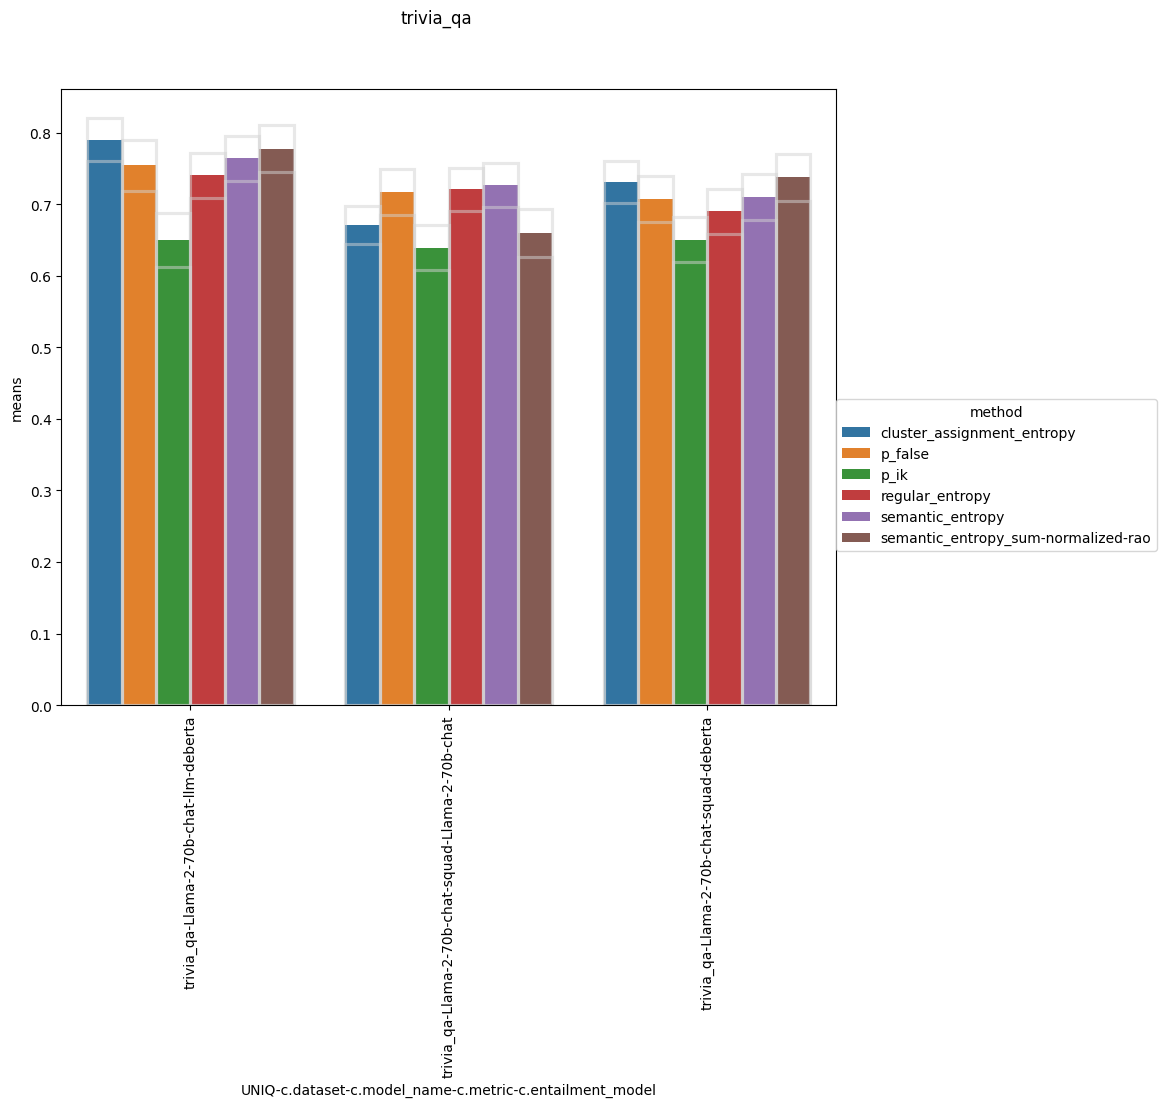

In [15]:
for dataset, gdf in all_runs.groupby('c.dataset'):

    plot_grouped(
        gdf.set_index('c.model_name').loc['Llama-2-70b-chat'].set_index('metric').loc['AUROC'].set_index('method').loc[main_methods].reset_index(),
        metric='means', x=uniq_name, hue='method',
    )
    plt.gcf().suptitle(dataset)